In [1]:
import matplotlib
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style ="whitegrid", font_scale=1.5)


/home/albert/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import plot_hourly_flight_distribution

LAX data not found at /data_1/albert/UAM-System-Model/uam_system_model/data/LAX_ind.csv. Downloading from GCS...
Download complete.


#### Prepare input

In [ ]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters/1600
    return distance_matrix

import numpy as np
from geopy.distance import geodesic
coordinates = np.array([(33.94417072663332, -118.40248449470265),
                        (34.043119432990345, -118.26720629762752),
                        (33.81606030845284, -118.15122129260827),
                        (34.17160155814583, -118.60525790222589),
                        (34.13843197335217, -118.35511311047983),
                        (33.812102161009804, -117.91897753216998),
                        (34.09174681098575, -118.32725521957076),
                        (34.08807589928915, -118.55063573741867),
                        (34.06666969690935, -118.4114352069469)])
                        
distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ['LAX', 'DTLA', 'LGB', 'WDHL', 'UVS', 'ANH', 'HWD', 'PSD', 'BVH']

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])
vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

#### Create instance variable

In [ ]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
)

#### Load demand & visualize

In [4]:
network.load_demand(
    month=8,
    day=1,
    directional_demand=4000,
    vertiport_pmf=vertiport_pmf,
)

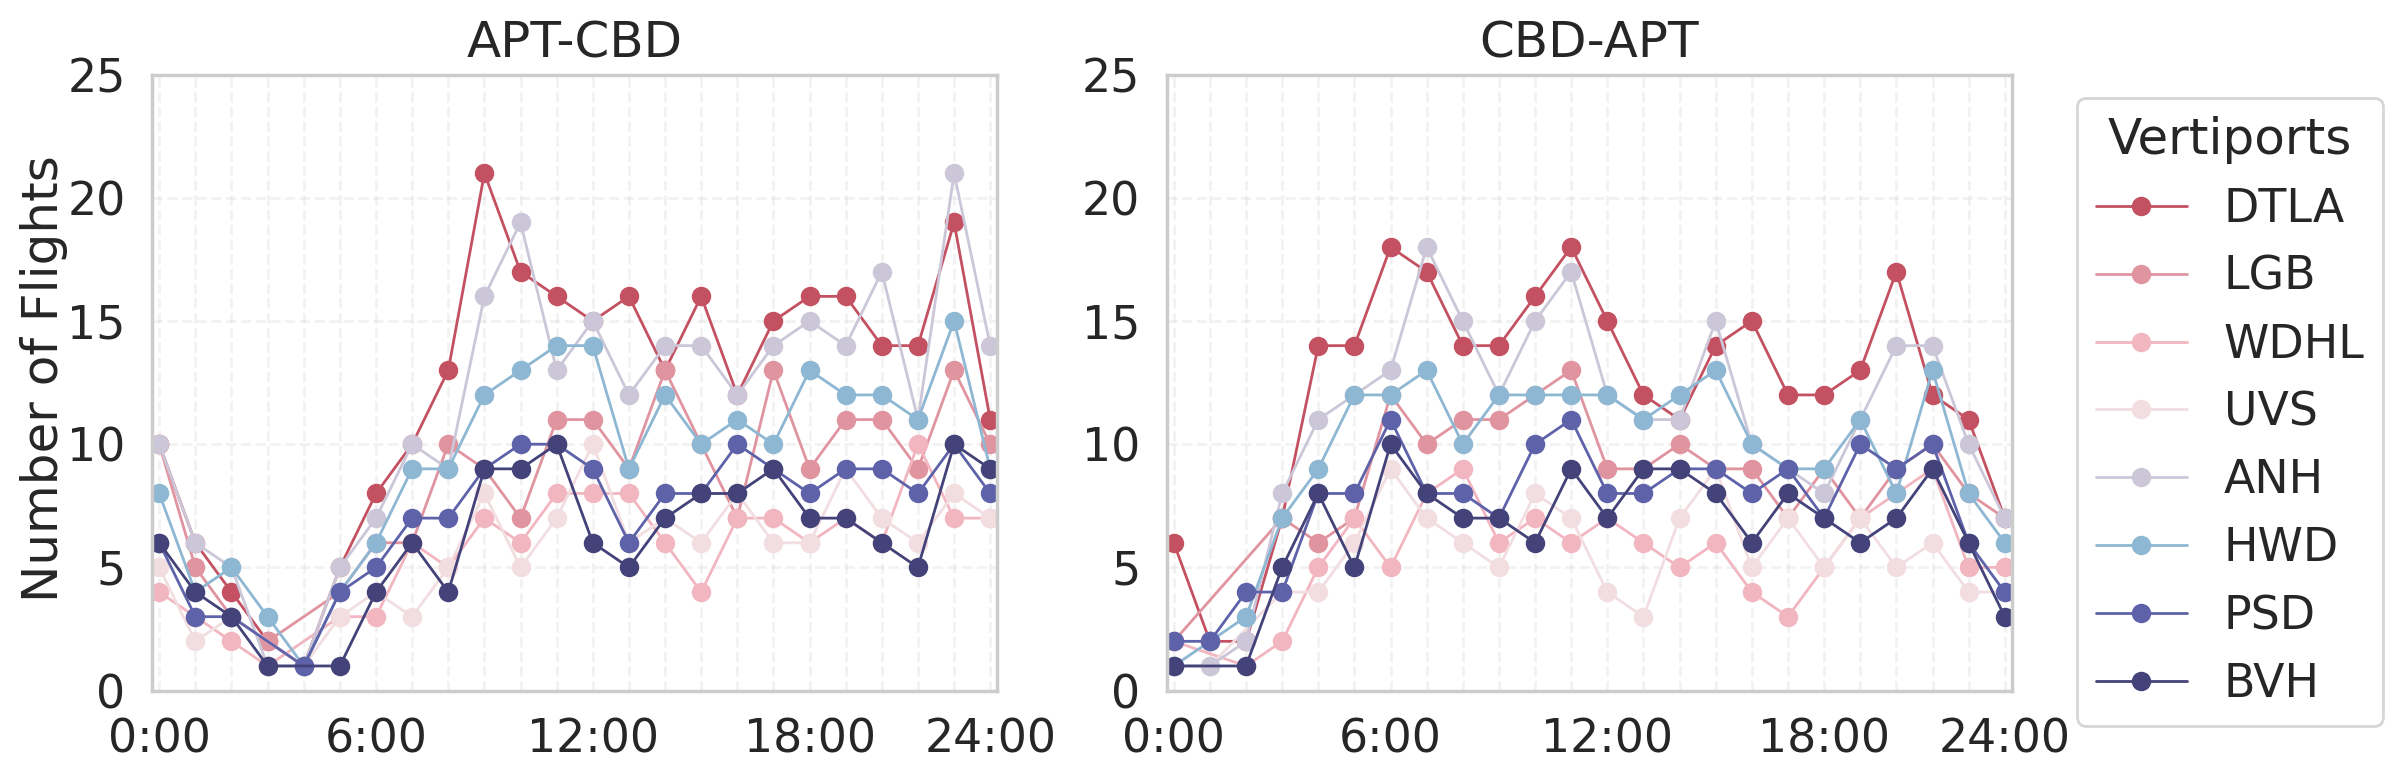

In [7]:
fig, ax = plot_hourly_flight_distribution(network, ylim=(0, 25))
plt.show()